# Problem Overview

### How to accurately identify and reduce the most significant risk factors of heart disease in a large, diverse population, using tools like machine learning to enhance prevention and early detection


### Why is it important to solve?
#### High prevalence of heart disease and its major risk factors among the U.S. population, and the need for improved identification and prevention strategies

# Getting Started

In [94]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, make_scorer, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import json

import seaborn as sns
import matplotlib.pyplot as plt


colors = ['skyblue', 'salmon', 'lightgreen', 'lightcoral', 'lightblue', 'lightyellow', 'lightpink', 'lightgray']


In [72]:

df = pd.read_csv('./data/heart_2022_with_nans.csv')

df.sample(20)

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
308380,Oregon,Male,Good,0.0,30.0,Within past 5 years (2 years but less than 5 y...,Yes,5.0,1 to 5,No,...,1.70,86.18,29.76,Yes,Yes,No,Yes,"Yes, received tetanus shot but not sure what type",No,No
140185,Louisiana,Female,Good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,58.97,22.31,Yes,NaN,No,No,NaN,No,Yes
314611,Pennsylvania,Female,Fair,2.0,20.0,Within past 5 years (2 years but less than 5 y...,Yes,7.0,1 to 5,No,...,1.65,81.65,29.95,Yes,Yes,No,Yes,NaN,No,No
128735,Kansas,Male,Good,0.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,5.0,1 to 5,No,...,1.80,129.73,39.89,Yes,No,No,No,"Yes, received tetanus shot, but not Tdap",No,Yes
172927,Massachusetts,Female,Excellent,0.0,0.0,Within past 5 years (2 years but less than 5 y...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
283829,North Dakota,Male,Good,2.0,17.0,Within past 2 years (1 year but less than 2 ye...,Yes,7.0,None of them,No,...,1.80,83.91,25.80,Yes,Yes,No,No,"Yes, received tetanus shot but not sure what type",No,Yes
245940,New Jersey,Female,Very good,30.0,0.0,Within past year (anytime less than 12 months ...,Yes,8.0,1 to 5,No,...,1.65,88.45,32.45,Yes,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No
61506,District of Columbia,Female,Good,3.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.60,113.40,44.29,Yes,Yes,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No
144194,Louisiana,Female,Poor,30.0,30.0,5 or more years ago,No,6.0,All,No,...,1.68,68.04,24.21,No,Yes,No,Yes,"No, did not receive any tetanus shot in the pa...",No,Yes
70897,Florida,Female,Fair,0.0,0.0,Within past year (anytime less than 12 months ...,No,7.0,None of them,No,...,1.70,83.91,28.97,Yes,Yes,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No


In [73]:
df.shape

(445132, 40)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445132 entries, 0 to 445131
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   State                      445132 non-null  object 
 1   Sex                        445132 non-null  object 
 2   GeneralHealth              443934 non-null  object 
 3   PhysicalHealthDays         434205 non-null  float64
 4   MentalHealthDays           436065 non-null  float64
 5   LastCheckupTime            436824 non-null  object 
 6   PhysicalActivities         444039 non-null  object 
 7   SleepHours                 439679 non-null  float64
 8   RemovedTeeth               433772 non-null  object 
 9   HadHeartAttack             442067 non-null  object 
 10  HadAngina                  440727 non-null  object 
 11  HadStroke                  443575 non-null  object 
 12  HadAsthma                  443359 non-null  object 
 13  HadSkinCancer              44

## EDA
### 1. Understand the Problem & Dataset
#### 1.1 Define Business Objective
#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images
### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers
#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers
    1. IQR method / Z-score
    2. Box plots
#### 4. Univariate Analysis
1. For Numeric features check distribution
2. For Categorical features check Frequency count
#### 5. Bivariate Analysis
1. Numerical v/s Target  
    1. Box plot
2. Categorical v/s Target  
    1. Count plot
#### 6. Multivariate Analysis
1. Correlation heatmaps for numeric features
2. Detect multicollinearity
#### 7. Encoding Categorical Features
1. Label Encoding for Ordinal categories
2. One-Hot Encoding for Nominal categories 
#### 8. Feature Scaling 
1. StandardScaler
#### 9. Feature Selection
1. Identify most relevant features 
    1. Is PCA good option?
#### 10. Feature Engineering
1. Create new meaningful features 
#### 11. Train-Test split 


###################################################################################################################################################

#### 1.2 Understand target variable
1. Identify feature types
    1. Numerical: continuous, discrete
    2. Categorical: nominal, ordinal
    3. Text / Dates / Images

<span style="color: green; font-weight: bold; font-size:24px">Target variable is "HadHeartAttack"</span>


In [84]:
numeric_columns = df.select_dtypes(exclude='object').columns
print(f"Numerical columns: {numeric_columns.to_list()} ")
print("-" * 120)

# For loop to get unique values of each object column and print the results
# for col in object_columns:      
#     print(f"Unique values in column '{col}':")
#     print(df[col].unique())
#     print("-" * 150)

Numerical columns: ['PhysicalHealthDays', 'MentalHealthDays', 'SleepHours', 'HeightInMeters', 'WeightInKilograms', 'BMI'] 
------------------------------------------------------------------------------------------------------------------------


In [76]:
# List columns with type as Object
object_columns = df.select_dtypes(include='object').columns.sort_values()
print("Object columns:", list(object_columns))
print("-" * 40)

# For loop to get unique values of each object column and print the results
for col in object_columns.sort_values():
    # print(f"Unique values in column '{col}':")
    # print(df[col].unique())
    print(df[col].value_counts(dropna=False, ascending=True))
    print("-" * 40)


Object columns: ['AgeCategory', 'AlcoholDrinkers', 'BlindOrVisionDifficulty', 'ChestScan', 'CovidPos', 'DeafOrHardOfHearing', 'DifficultyConcentrating', 'DifficultyDressingBathing', 'DifficultyErrands', 'DifficultyWalking', 'ECigaretteUsage', 'FluVaxLast12', 'GeneralHealth', 'HIVTesting', 'HadAngina', 'HadArthritis', 'HadAsthma', 'HadCOPD', 'HadDepressiveDisorder', 'HadDiabetes', 'HadHeartAttack', 'HadKidneyDisease', 'HadSkinCancer', 'HadStroke', 'HighRiskLastYear', 'LastCheckupTime', 'PhysicalActivities', 'PneumoVaxEver', 'RaceEthnicityCategory', 'RemovedTeeth', 'Sex', 'SmokerStatus', 'State', 'TetanusLast10Tdap']
----------------------------------------
AgeCategory
NaN                 9079
Age 25 to 29       21990
Age 30 to 34       25807
Age 18 to 24       26941
Age 35 to 39       28526
Age 45 to 49       28531
Age 40 to 44       29942
Age 75 to 79       32518
Age 50 to 54       33644
Age 80 or older    36251
Age 55 to 59       36821
Age 70 to 74       43472
Age 60 to 64       44511

In [77]:
boolean_columns = ["AlcoholDrinkers", "BlindOrVisionDifficulty", "ChestScan", "DeafOrHardOfHearing", "DifficultyDressingBathing", "DifficultyWalking", "FluVaxLast12", "HIVTesting", "HadAngina", "HadArthritis", "HadAsthma", "HadCOPD", "HadDepressiveDisorder", "HadKidneyDisease", "HadSkinCancer", "HadStroke", "HighRiskLastYear"]

for col in boolean_columns:
    print(df[col].value_counts(dropna=False))
    print("-" * 40)

AlcoholDrinkers
Yes    210891
No     187667
NaN     46574
Name: count, dtype: int64
----------------------------------------
BlindOrVisionDifficulty
No     399910
Yes     23658
NaN     21564
Name: count, dtype: int64
----------------------------------------
ChestScan
No     223221
Yes    165865
NaN     56046
Name: count, dtype: int64
----------------------------------------
DeafOrHardOfHearing
No     385539
Yes     38946
NaN     20647
Name: count, dtype: int64
----------------------------------------
DifficultyDressingBathing
No     404404
NaN     23915
Yes     16813
Name: count, dtype: int64
----------------------------------------
DifficultyWalking
No     353039
Yes     68081
NaN     24012
Name: count, dtype: int64
----------------------------------------
FluVaxLast12
Yes    209256
No     188755
NaN     47121
Name: count, dtype: int64
----------------------------------------
HIVTesting
No     249919
Yes    129086
NaN     66127
Name: count, dtype: int64
-------------------------------

### 2. Data Collection and Overview
1. Check duplicates
2. Check Nulls
3. Check outliers

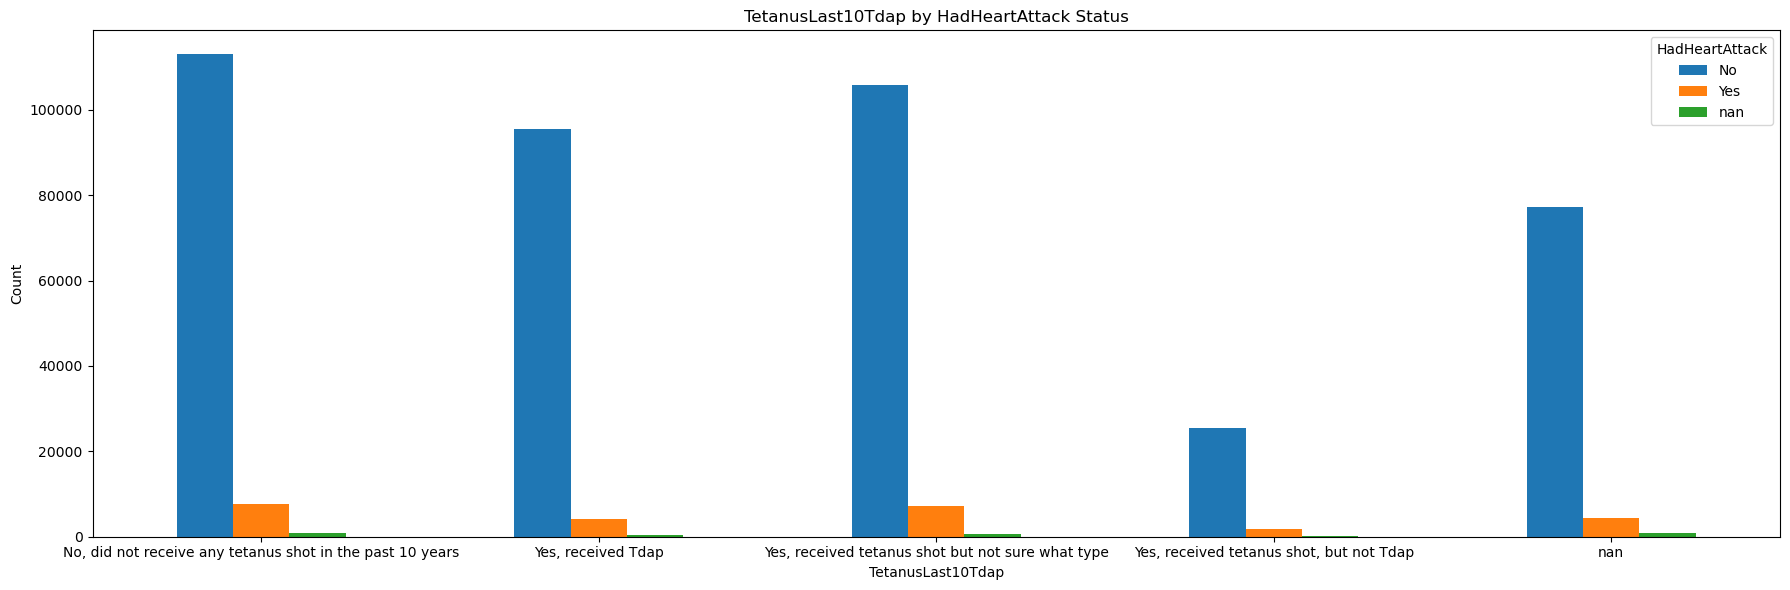

In [ ]:

import matplotlib.pyplot as plt

# Convert result to DataFrame for easier plotting
result_df = result.unstack(level=1).fillna(0)

# Plot bar chart for TetanusLast10Tdap counts by HadHeartAttack status
ax = result_df.plot(kind='bar', figsize=(18, 6))
ax.set_xlabel('TetanusLast10Tdap')
ax.set_ylabel('Count')
ax.set_title('TetanusLast10Tdap by HadHeartAttack Status')
plt.xticks(rotation=0)
plt.legend(title='HadHeartAttack')
plt.tight_layout()
plt.show()




In [70]:
# Percentage of null values in each column
nan_percent = df.isna().mean().mul(100).to_frame('NaN %')

nan_percent.sort_values(by='NaN %', ascending=False)


,NaN %
TetanusLast10Tdap,18.537423
PneumoVaxEver,17.307226
HIVTesting,14.855593
ChestScan,12.590872
CovidPos,11.404258
HighRiskLastYear,11.372582
BMI,10.964388
FluVaxLast12,10.585849
AlcoholDrinkers,10.462964
WeightInKilograms,9.452926



<span style="color:red"># Following columns may be dropped because it has more than 15% of the rows with No Data</span> 


In [24]:
# Query nan_percent to give records which are more than 15%
high_nan = nan_percent[nan_percent['NaN %'] > 15].sort_values(by='NaN %', ascending=False)
print(high_nan)


                       NaN %
TetanusLast10Tdap  18.537423
PneumoVaxEver      17.307226


In [27]:
# Number of rows with all NULL values

num_rows_all_null = df.isnull().all(axis=1).sum()
print(f"Number of rows with all columns NULL: {num_rows_all_null}")
print("-" * 120)

# Find duplicate records in the dataframe
duplicate_rows = df[df.duplicated(keep=False)]
print(f"Number of duplicate records: {len(duplicate_rows)}")
if not duplicate_rows.empty:
    print("Sample duplicate records:")
    display(duplicate_rows.head())


Number of rows with all columns NULL: 0
------------------------------------------------------------------------------------------------------------------------
Number of duplicate records: 302
Sample duplicate records:


,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,HeightInMeters,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
4712,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7310,Alaska,Male,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10696,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
11503,Arizona,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,1.63,56.7,21.46,Yes,No,Yes,Yes,"Yes, received Tdap",No,No
26789,California,Male,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,None of them,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Outlier summary for numeric columns:


,Column,Num Outliers,Percent Outliers,Max Outlier,Min Outlier
3,PhysicalHealthDays,72268,16.65,30.00,8.00
2,MentalHealthDays,60389,13.85,30.00,13.00
0,BMI,12339,3.11,99.64,12.02
5,WeightInKilograms,9643,2.39,292.57,22.68
4,SleepHours,7260,1.65,24.00,1.00
1,HeightInMeters,1556,0.37,2.41,0.91


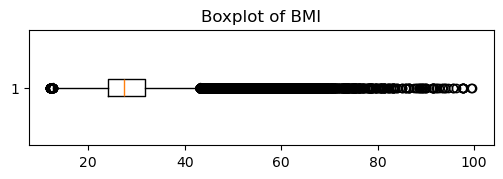

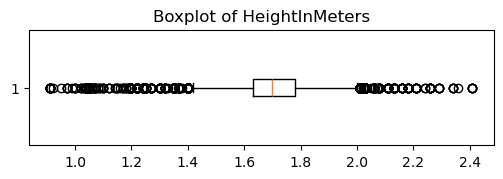

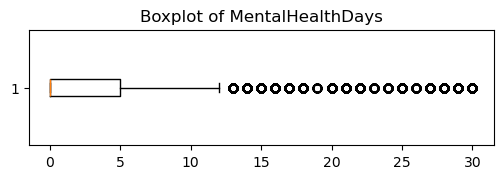

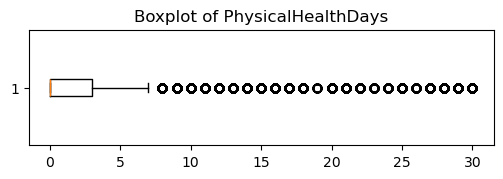

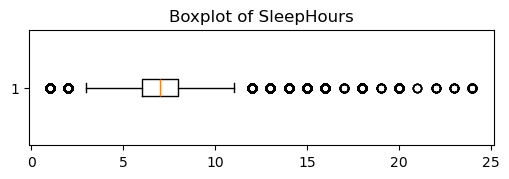

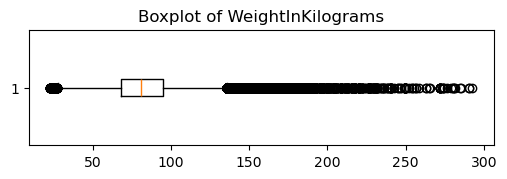

In [112]:
# Check for outliers in numeric data columns using IQR method

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns.sort_values()

# print(numeric_columns)

outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Outlier", "Min Outlier"])

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_outlier = outliers.max()
    min_outlier = outliers.min()        
    outlier_summary.loc[len(outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), max_outlier, min_outlier]

print("Outlier summary for numeric columns:")
display(outlier_summary.sort_values(by="Percent Outliers", ascending=False))

# Visualize outliers for each numeric column
import matplotlib.pyplot as plt
for col in numeric_columns:
    plt.figure(figsize=(6, 1.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()


In [117]:
from scipy.stats import zscore

# Calculate Z-scores for numeric columns
z_scores = df[numeric_columns].dropna().apply(zscore)

# print(z_scores)

# Set a threshold for Z-score to identify outliers (commonly 3 or -3)
z_threshold = 3

z_outlier_summary = pd.DataFrame(columns=["Column", "Num Outliers", "Percent Outliers", "Max Z", "Min Z"])

for col in numeric_columns:
    # Find outliers based on Z-score
    outliers = z_scores[(z_scores[col].abs() > z_threshold)][col]
    num_outliers = outliers.count()
    percent_outliers = (num_outliers / df[col].count()) * 100 if df[col].count() > 0 else 0
    max_z = df[col].max()
    min_z = df[col].min()
    z_outlier_summary.loc[len(z_outlier_summary)] = [col, num_outliers, round(percent_outliers, 2), round(max_z, 2), round(min_z, 2)]

print("Outlier summary for numeric columns using Z-Score:")
display(z_outlier_summary.sort_values(by="Percent Outliers", ascending=False))


Outlier summary for numeric columns using Z-Score:


,Column,Num Outliers,Percent Outliers,Max Z,Min Z
2,MentalHealthDays,22929,5.26,30.00,0.00
4,SleepHours,5899,1.34,24.00,1.00
0,BMI,4806,1.21,99.64,12.02
5,WeightInKilograms,3960,0.98,292.57,22.68
1,HeightInMeters,824,0.20,2.41,0.91
3,PhysicalHealthDays,0,0.00,30.00,0.00


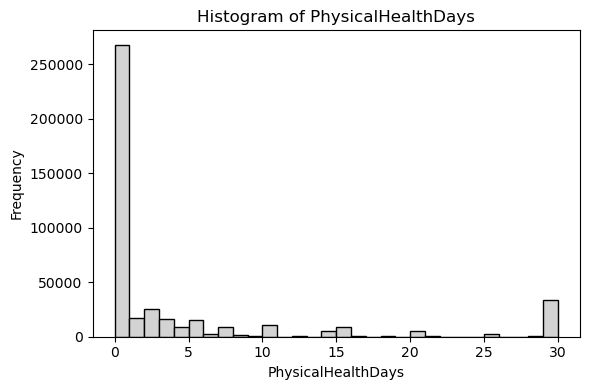

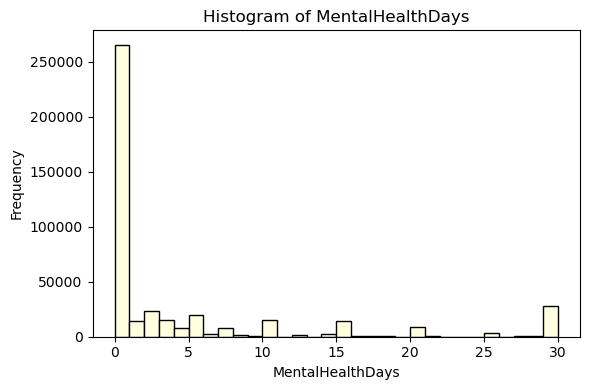

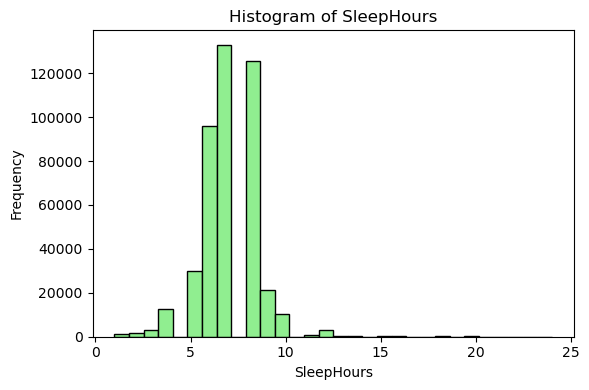

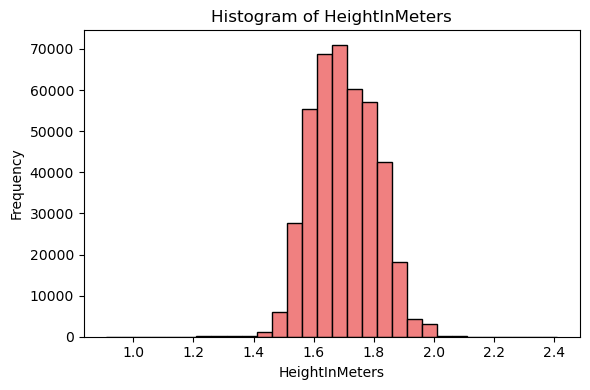

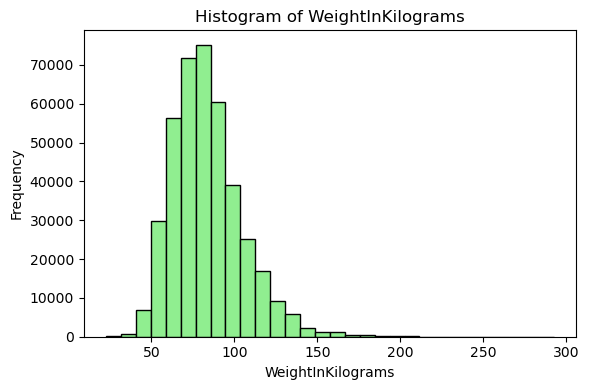

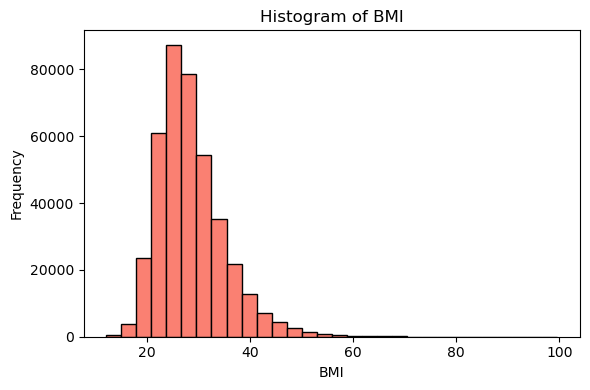

In [95]:
# Plot histogram for all numeric columns except "HadHeartAttack"
import random
import matplotlib.pyplot as plt

columns_to_plot = df.select_dtypes(exclude='object').columns

for col in columns_to_plot:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col].dropna(), bins=30, color=colors[random.randint(0, len(colors) - 1)], edgecolor='black')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Histogram of {col}")

    plt.tight_layout()
    plt.show()


#### 3. Data Cleaning
1. Handle Missing Values
2. Handle Duplicates
3. Handle Outliers

In [78]:
# Create a copy of the original dataframe
df_original = df.copy()

In [79]:
# Remove duplicate records from df
print(f"Number of duplicate records before removing duplicates: {len(df)}")
df = df.drop_duplicates()
print(f"Number of duplicate records after removing duplicates: {len(df)}")


Number of duplicate records before removing duplicates: 445132
Number of duplicate records after removing duplicates: 444975


##### Handling Missing Values for Numeric columns

##### Handling Missing Values for Categorical columns

In [81]:

# # Bivariate analysis
# for bool_column in boolean_columns:
#     plt.figure(figsize=(6, 4))
#     sns.countplot(data=df, x=bool_column, hue="HadHeartAttack")
#     plt.show()

In [ ]:
df["MentalHealthDays"].unique()

array([ 0.,  3.,  9.,  5., 15., 20., 14., 10., 18.,  1., nan,  2., 30.,
        4.,  6.,  7., 25.,  8., 22., 29., 27., 21., 12., 28., 16., 13.,
       26., 17., 11., 23., 19., 24.])

In [ ]:
df_original = df.copy

In [ ]:
encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])

# show all unique values of the Gender column
print(df["Sex"].unique())
print("-" * 40)

# null values in each column
# print(df.isnull().sum().sort_values(ascending=False))
# print("-" * 40)

null_df = pd.DataFrame(columns = ["Column", "Null Count", "Null %"])

for col in df.columns.sort_values():
    null_count = df[col].isnull().sum()
    null_percent = (null_count / len(df)) * 100
    null_df.loc[len(null_df)] = [col, null_count, null_percent.round(2)]
    
    # print(f"Column: {col}")
    # print(f"  Null count: {null_count}")
    # print(f"  Null percentage: {null_percent:.2f}%")
    # print("-" * 40)

null_df.sort_values(by="Null %", ascending=False)


# # drop the columns with more than 10% null values
# df = df.dropna(thresh=0.9 * len(df))

# # drop the columns with all null values
# df = df.dropna(axis=1, how="all")

[0 1]
----------------------------------------


,Column,Null Count,Null %
38,TetanusLast10Tdap,82516,18.54
31,PneumoVaxEver,77040,17.31
14,HIVTesting,66127,14.86
4,ChestScan,56046,12.59
5,CovidPos,50764,11.40
26,HighRiskLastYear,50623,11.37
2,BMI,48806,10.96
12,FluVaxLast12,47121,10.59
1,AlcoholDrinkers,46574,10.46
39,WeightInKilograms,42078,9.45
